In [1]:
import math

from scipy.io import arff
from operator import index

import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import NearestNeighbors, KernelDensity
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import scipy.stats
from scipy.stats import expon, skew, norm,gamma, anderson,goodness_of_fit, monte_carlo_test, probplot, skewnorm
from scipy import integrate
from sklearn.metrics import auc
import seaborn as sns
import math

from statsmodels.sandbox.distributions.gof_new import kstest

plt.rcParams['figure.figsize'] = [15, 7]
import warnings
from scipy import stats

warnings.filterwarnings('ignore')

In [2]:
def setupDf(fileName):
    arff_file = arff.loadarff(f'./{fileName}') # import the attribute-relation file format
    df4 = pd.DataFrame(arff_file[0])
    if fileName[0] == 'c': # checks if the file is a synthetic dataset
        X = df4.iloc[:,:2].values
        y = df4.iloc[:,2].values
        le = LabelEncoder()
        y = le.fit_transform(y)
    else:
        #drop the outlier and id columns for the independent variables.
        X = df4.drop(columns=['outlier','id']).values
        #get outlier values
        y = df4['outlier'].values
        le = LabelEncoder()
        #encoded the variables as 0=non-outlier, 1=outlier
        y = le.fit_transform(y)
    return X, y

def main(X, y, n):
    #find the nearestNeighbors
    nn = NearestNeighbors(n_neighbors=n,p=1)
    nn.fit(X, y)
    #return the dist of each and the nearest neighbors
    dist, knn = nn.kneighbors(X)  # returns N index neighbors including self
    return knn, dist

def generateArr(newDist, distanceMetric='max'):
    arr = []
    #returns an array based on the median and max values
    for x in newDist:  # finds the distance away from that point (index 0)
        if distanceMetric == 'median':
            arr += [np.median(x)]
        elif distanceMetric == 'sum':  # min + median + max
            arr += [x[1] + np.max(x) + np.median(x)]
        elif distanceMetric == 'max':
            arr += [np.max(x)]
        elif distanceMetric == 'minMax':
            arr += [np.max(x) + x[1]]
        elif distanceMetric == 'medMax':
            arr += [np.median(x) + np.max(x)]
        elif distanceMetric == 'max2':
            arr += [x[-1]+x[-2]]

    return arr

def outputResults(X,y,lowerRange=2,upperRange=70):
    tots = []
    posNeg4 = []
    for v in range(lowerRange,upperRange):
        knn, distReturn = main(X, y, v) # returns index and distance of points
        distReturn = np.array(distReturn)
        arr = generateArr(distReturn, distanceMetric="medMax") # return arr of max values
        params = gamma.fit(arr) # fit params for gamma distribution
        posNeg4 = []
        spaceStep4 = np.linspace(0,.99,30) # threshold from 0 to .99, 30 samples
        for e in spaceStep4:
            newArr = arr > gamma.ppf(e,params[0],loc=params[1], scale=params[2]) # if arr value is outside threshold add to new array
            posNeg4.append([((y[newArr] == 1).sum() / (y == 1).sum()), (y[newArr] != 1).sum()/ ((y != 1).sum())]) # True positive rate, false positive rate

        posNeg4 = np.array(posNeg4)
        arrtest1, arrtest2 = np.split(posNeg4, 2,axis=1) # split the array
        tots += [auc(arrtest2, arrtest1)] # return the area under the curve

    return tots

def printResults(arr):
    arr = np.nan_to_num(arr)
    arr = list(arr)
    print(max(arr),arr.index(max(arr))+2,arr) #print the max values, the k value, and the array

def qqPlots(X,y,kValue,name):
    knn, distReturn = main(X, y, kValue)
    distReturn = np.array(distReturn)
    arr = generateArr(distReturn, distanceMetric="medMax")
    params = gamma.fit(arr)
    print(f"a: {params[0]} Loc: {params[1]}, Scale: {params[2]}")
    print(skew(arr),np.var(arr))
    fig, ax = plt.subplots(2,1)
    results = probplot(arr,dist=stats.gamma, plot=ax[0],sparams=(params[0],params[1],params[2]),rvalue=True)
    fig.suptitle(name)
    dista = plt.hist(arr,bins=int(np.sqrt(len(arr))),density=True)
    sns.kdeplot(arr,bw=.3)
    plt.xlabel("Maximum Manhattan Distance")
    plt.ylabel("Density")
    plt.show()

0.7597584752506763 46 [0.7430168709215342, 0.75160154384848, 0.7499005252268025, 0.7497612605443259, 0.6157985834792297, 0.613739455674041, 0.5993156135604012, 0.7533920897660352, 0.7539590959732612, 0.7528549259907689, 0.7538198312907847, 0.7546156294763647, 0.7555009549578227, 0.7567443896227916, 0.7551826356835906, 0.7557595893681361, 0.7561972783702052, 0.7569035492599077, 0.6168430685978036, 0.7556899570268978, 0.7566349673722744, 0.5825342193219799, 0.60456788158523, 0.5764165207703327, 0.7558292217093744, 0.7552522680248288, 0.7565653350310361, 0.7582763011300333, 0.7570726563743434, 0.7575003978990927, 0.757848559605284, 0.6990589686455515, 0.7586841477001433, 0.7589029922011776, 0.7588830972465382, 0.7591516791341715, 0.7581967213114754, 0.7581967213114752, 0.7574108706032151, 0.7585548304949865, 0.7586742002228235, 0.7576197676269298, 0.7580375616743592, 0.7587836224733407, 0.7597584752506763, 0.7592113639980901, 0.7583459334712717, 0.7570129715104249, 0.7576893999681681, 0.7

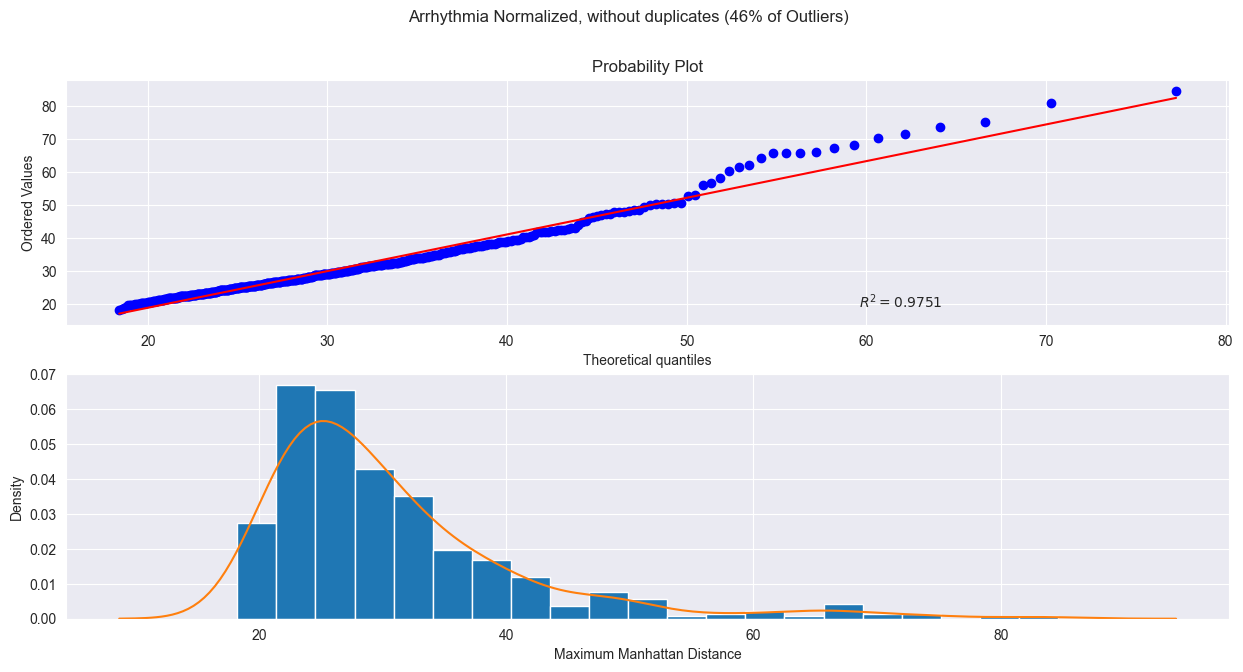

In [3]:
X, y = setupDf("real/Arrhythmia_withoutdupl_norm_46.arff")
endResults = outputResults(X,y)
printResults(endResults)
qqPlots(X,y,46,"Arrhythmia Normalized, without duplicates (46% of Outliers)")

0.738732993197279 6 [0.6517148526077096, 0.6749574829931972, 0.7132936507936507, 0.7153486394557823, 0.738732993197279, 0.7229308390022676, 0.7128684807256235, 0.704719387755102, 0.6958616780045352, 0.698625283446712, 0.6830357142857143, 0.6669501133786848, 0.6546910430839002, 0.6465419501133787, 0.6396683673469388, 0.6346371882086168, 0.6214569160997732, 0.6177012471655329, 0.6165674603174603, 0.6091978458049887, 0.6082766439909297, 0.609906462585034, 0.6045918367346939, 0.6094104308390023, 0.6004818594104309, 0.5904195011337868, 0.5873015873015872, 0.580640589569161, 0.5736252834467119, 0.5678146258503401, 0.5683815192743764, 0.5656179138321995, 0.564625850340136, 0.5617913832199547, 0.5638463718820861, 0.5663973922902494, 0.5634920634920635, 0.5617205215419501, 0.5610119047619049, 0.5547760770975056, 0.5505952380952381, 0.5555555555555556, 0.5509495464852607, 0.5471230158730158, 0.5454931972789117, 0.5509495464852607, 0.5498157596371882, 0.5455640589569162, 0.5423044217687074, 0.540

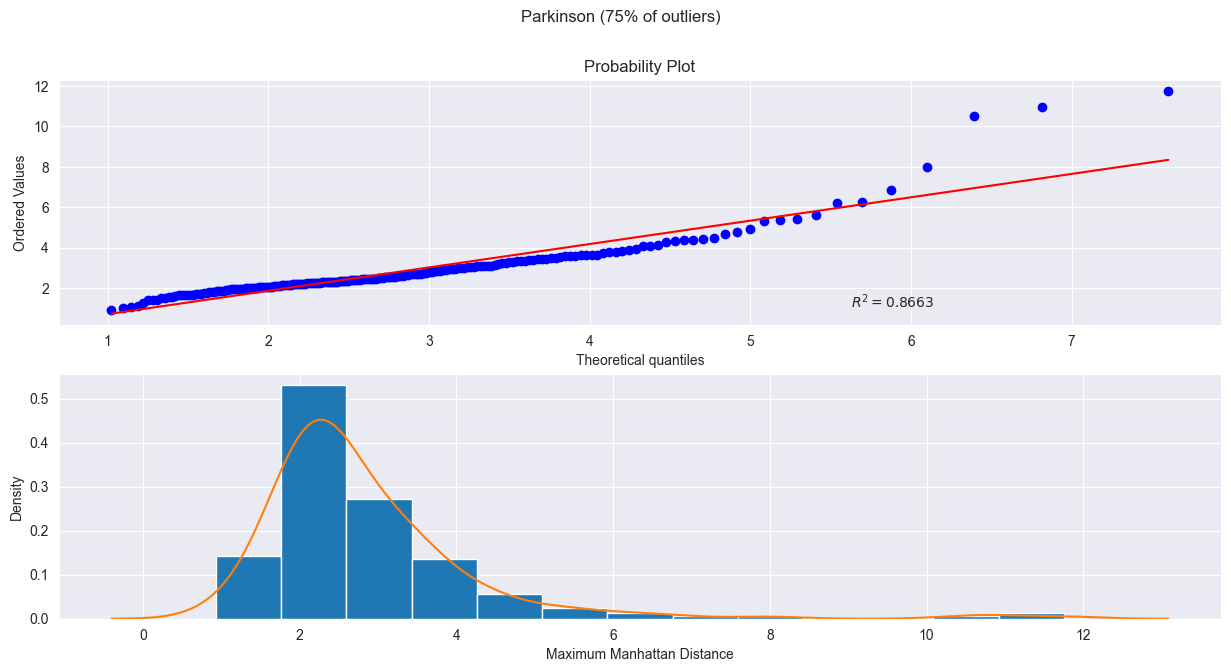

In [4]:
X, y = setupDf("real/Parkinson_withoutdupl_norm_75.arff")
endResults = outputResults(X,y)
printResults(endResults)
qqPlots(X,y,6,"Parkinson (75% of outliers)")

0.8242307692307692 9 [0.35196153846153844, 0.36903846153846154, 0.49915384615384617, 0.6934615384615385, 0.7269615384615384, 0.7585769230769231, 0.8099230769230771, 0.8242307692307692, 0.8075384615384614, 0.8116153846153847, 0.7961153846153847, 0.783423076923077, 0.7956923076923077, 0.7929615384615385, 0.7838846153846153, 0.7817307692307692, 0.7795000000000001, 0.7763461538461538, 0.765923076923077, 0.7759230769230768, 0.7714230769230768, 0.7746923076923077, 0.7686538461538462, 0.7631538461538461, 0.7641538461538462, 0.7565000000000001, 0.7601538461538462, 0.7565, 0.7583461538461539, 0.7528846153846153, 0.7579999999999999, 0.7523461538461538, 0.7521923076923077, 0.7466923076923077, 0.7433461538461537, 0.7402307692307692, 0.7446923076923078, 0.7401153846153844, 0.7431923076923077, 0.7380384615384615, 0.7416923076923077, 0.7460769230769232, 0.7308076923076923, 0.7303076923076923, 0.7258076923076924, 0.7316153846153847, 0.7286923076923078, 0.7242307692307691, 0.7249999999999999, 0.7223461

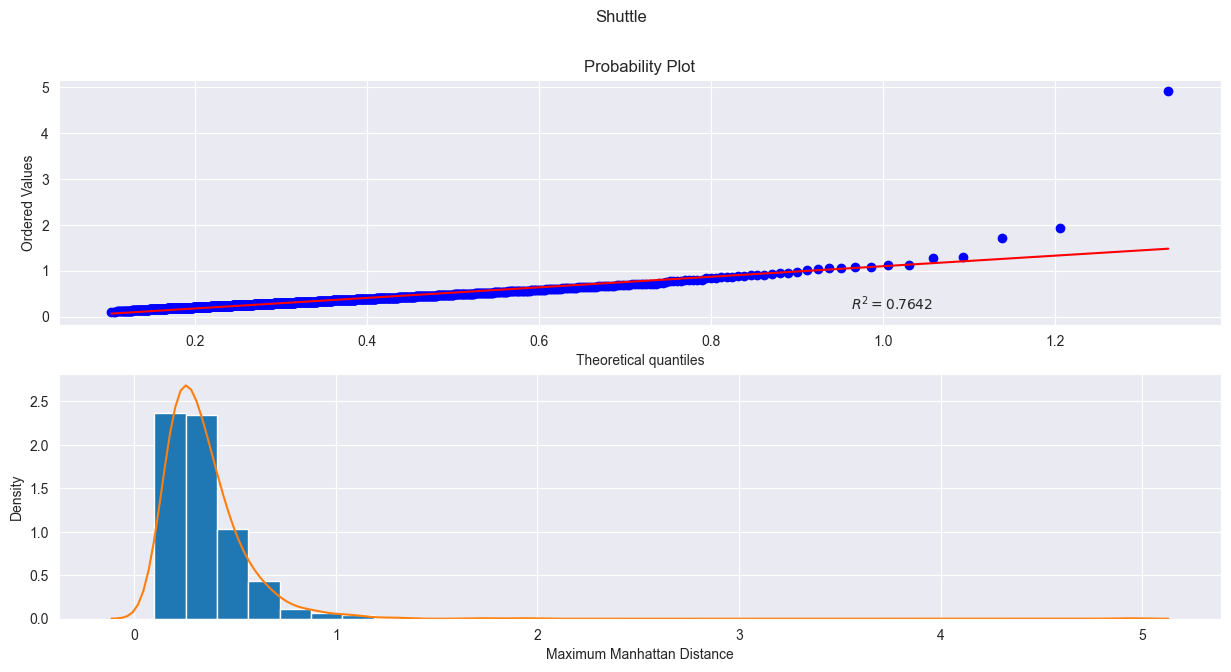

In [5]:
X, y = setupDf("real/Shuttle_withoutdupl_norm_v10.arff")
endResults = outputResults(X,y)
printResults(endResults)
qqPlots(X,y,9,"Shuttle")

0.9976525821596245 27 [0.8544600938967135, 0.97018779342723, 0.9892018779342723, 0.9833333333333334, 0.9938967136150236, 0.9786384976525822, 0.983568075117371, 0.9943661971830988, 0.9943661971830986, 0.9901408450704224, 0.9922535211267606, 0.971830985915493, 0.9915492957746478, 0.9880281690140846, 0.9936619718309858, 0.9873239436619718, 0.9946009389671361, 0.9922535211267607, 0.9906103286384977, 0.9892018779342723, 0.9877934272300469, 0.9922535211267607, 0.994131455399061, 0.9941314553990612, 0.9943661971830986, 0.9976525821596245, 0.9976525821596245, 0.9976525821596245, 0.9948356807511738, 0.9969483568075117, 0.9950704225352112, 0.9889671361502348, 0.9936619718309858, 0.9953051643192488, 0.9948356807511737, 0.9948356807511736, 0.9948356807511736, 0.9976525821596245, 0.9976525821596244, 0.9974178403755869, 0.9969483568075117, 0.9969483568075116, 0.9955399061032865, 0.9974178403755869, 0.9971830985915493, 0.995774647887324, 0.9955399061032865, 0.9953051643192489, 0.9953051643192489, 0.9

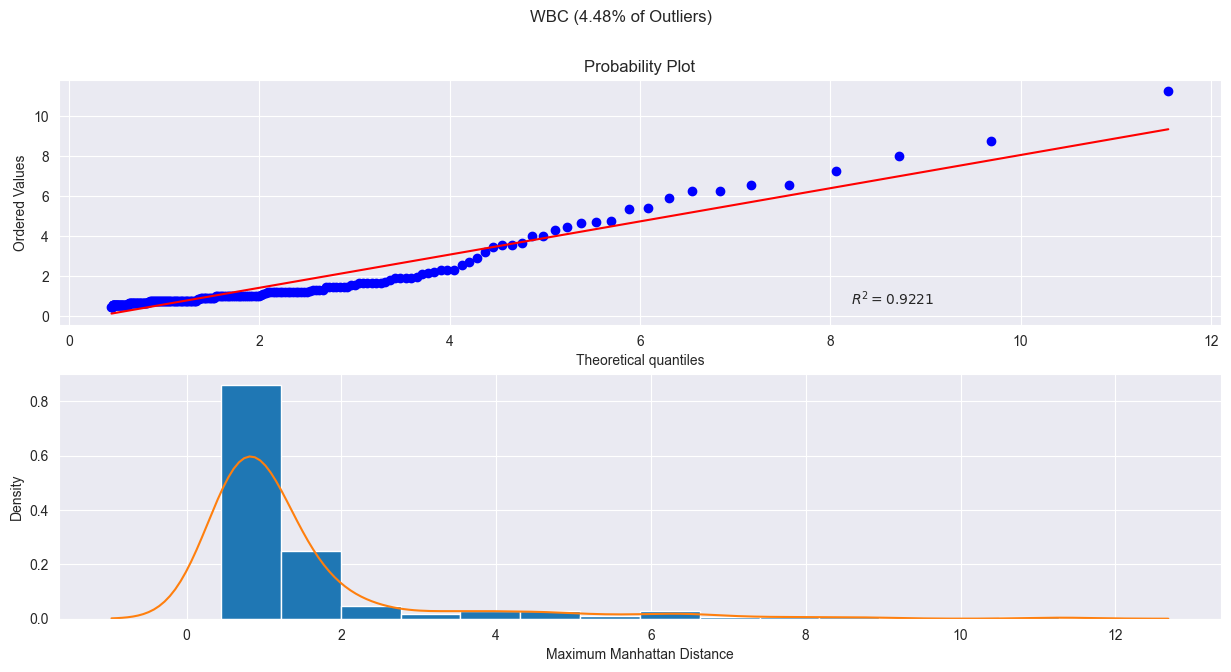

In [6]:
X, y = setupDf("real/WBC_withoutdupl_norm_v10.arff")
endResults = outputResults(X,y)
printResults(endResults)
qqPlots(X,y,27,"WBC (4.48% of Outliers)")

0.6497485458870182 49 [0.40957040526684807, 0.4479953172473066, 0.483277936309286, 0.5046025314570909, 0.5232199838285295, 0.5429634784870438, 0.5574071883882056, 0.5634370924148642, 0.5762492837810329, 0.5867861841361269, 0.5936894512254883, 0.5995031937711568, 0.6055727961188472, 0.609906509864974, 0.6123020738308667, 0.6144658090258668, 0.6197369685843745, 0.6244843930232733, 0.6276741590081498, 0.6299142280667365, 0.6315267809350049, 0.6324367795402629, 0.6338138518633001, 0.6354767049780988, 0.6363971877096825, 0.6371138778733574, 0.6375397218808665, 0.6375699962681222, 0.6388037069985902, 0.6399383486252365, 0.6401732401746068, 0.6407152341659067, 0.6416703498541175, 0.6427883817974834, 0.6433823252237241, 0.64411244449303, 0.6455090714786529, 0.6461636814785775, 0.6470948839348317, 0.6470504736469115, 0.647141296808679, 0.647122566740299, 0.647435676940011, 0.6471686262166298, 0.6477919016367487, 0.6483731227523918, 0.6491591966284935, 0.6497485458870182, 0.6492235149765154, 0.6

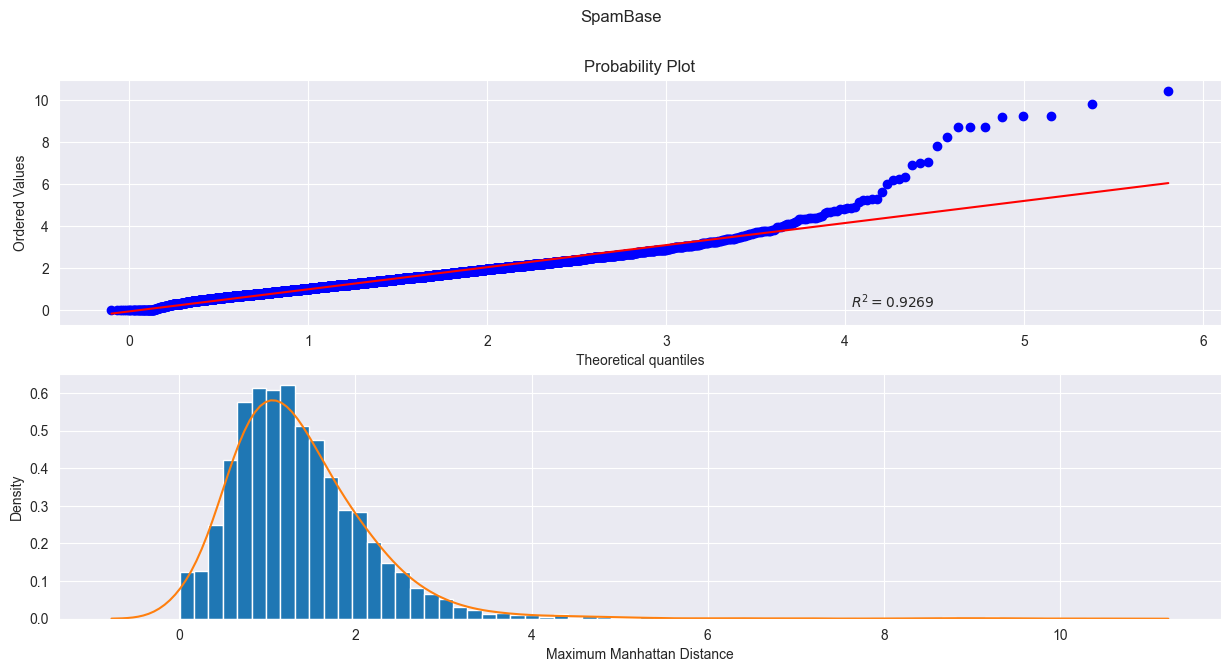

In [7]:
X, y = setupDf("real/SpamBase_withoutdupl_norm_40.arff")
endResults = outputResults(X,y)
printResults(endResults)
qqPlots(X,y,49,"SpamBase")

0.5326898689587148 21 [0.46322389742144565, 0.4855572777229816, 0.505706636607017, 0.5123996054670987, 0.5232492602508102, 0.5210652388333098, 0.5185994082006482, 0.5165562913907286, 0.5246583063266168, 0.5202902634916162, 0.5264900662251655, 0.5242355925038746, 0.5210652388333098, 0.5220515710863746, 0.5208538819219388, 0.5203607157954065, 0.522615189516697, 0.5288149922502466, 0.526983232351698, 0.5326898689587148, 0.5280400169085528, 0.5290968014654079, 0.5269832323516978, 0.5290968014654078, 0.5280400169085528, 0.5281809215161336, 0.5221220233901648, 0.5205016204029871, 0.5214879526560519, 0.5226151895166972, 0.5236719740735521, 0.5228265464280683, 0.5202198111878258, 0.5169790052134704, 0.5166267436945187, 0.5190925743271806, 0.5199380019726645, 0.5254332816683106, 0.5243764971114555, 0.5232492602508102, 0.5193743835423419, 0.5192334789347612, 0.5201493588840354, 0.520290263491616, 0.5215584049598421, 0.520712977314358, 0.5172608144286318, 0.5176835282513736, 0.5169085529096801, 0

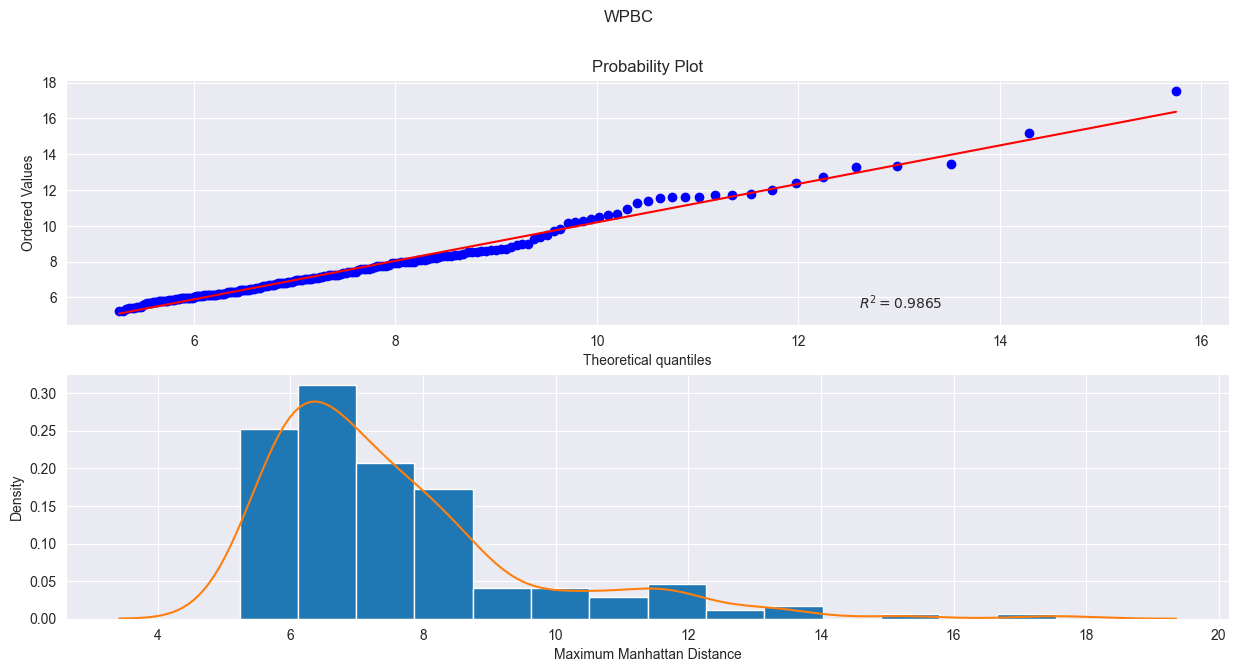

In [8]:
X, y = setupDf("real/WPBC_withoutdupl_norm.arff")
endResults = outputResults(X, y)
printResults(endResults)
qqPlots(X,y,21,"WPBC")

0.6813888888888888 69 [0.6128333333333335, 0.6222222222222222, 0.6239722222222222, 0.6243611111111113, 0.6261944444444445, 0.6274166666666667, 0.627361111111111, 0.6328055555555556, 0.6346111111111111, 0.6364166666666665, 0.6386944444444445, 0.6430833333333333, 0.6430277777777778, 0.6444444444444445, 0.6513333333333333, 0.6514166666666666, 0.6528888888888889, 0.6538333333333334, 0.6524722222222221, 0.6546666666666665, 0.6568055555555554, 0.6577500000000001, 0.6567777777777779, 0.6559722222222222, 0.660138888888889, 0.6602777777777776, 0.6603333333333333, 0.6620833333333334, 0.6629444444444446, 0.6647777777777777, 0.6621388888888889, 0.6605, 0.6614444444444444, 0.6628055555555555, 0.6638333333333333, 0.6645555555555555, 0.6637222222222222, 0.6630555555555556, 0.6643611111111111, 0.6629722222222224, 0.6649166666666667, 0.6642222222222223, 0.6663611111111113, 0.667611111111111, 0.6657222222222223, 0.6649444444444444, 0.66725, 0.6647222222222222, 0.6681111111111112, 0.6725000000000001, 0.6

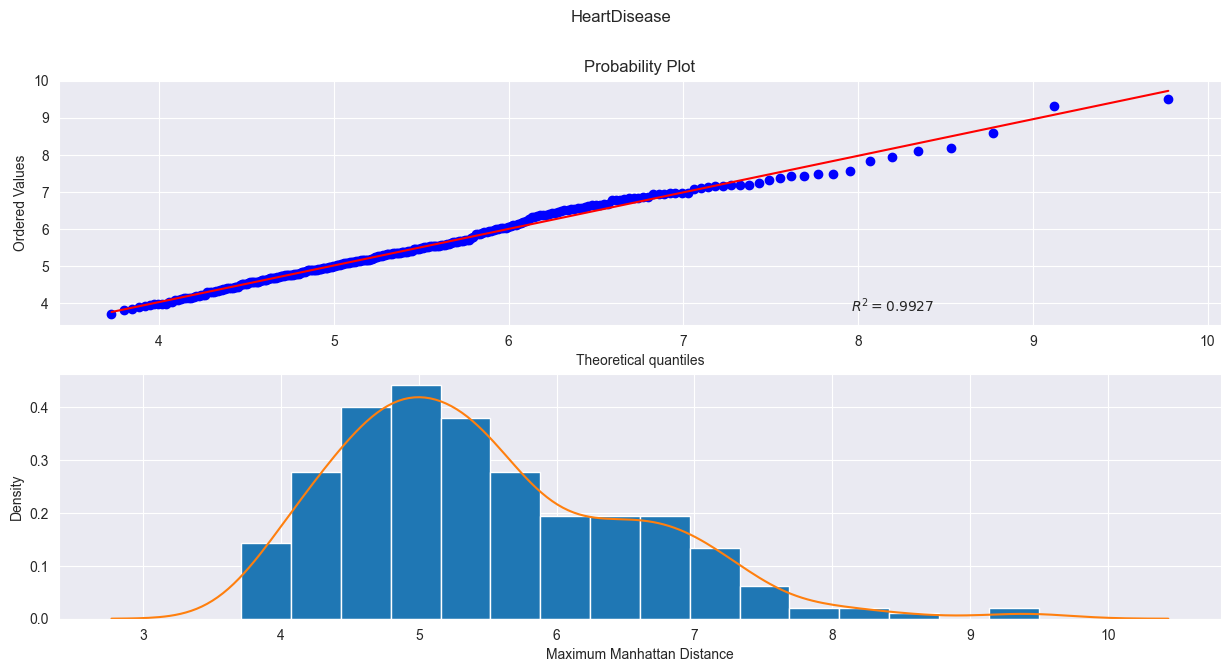

In [9]:
X, y = setupDf("real/HeartDisease_withoutdupl_norm_44.arff")
endResults = outputResults(X, y)
printResults(endResults)
qqPlots(X,y,69,"HeartDisease")

0.8813008130081301 2 [0.8813008130081301, 0.8544715447154472, 0.8560975609756097, 0.8547425474254744, 0.8639566395663957, 0.862330623306233, 0.8688346883468835, 0.8658536585365854, 0.8699186991869919, 0.8655826558265582, 0.8682926829268293, 0.873170731707317, 0.8720867208672086, 0.87289972899729, 0.8747967479674796, 0.8747967479674796, 0.8663956639566396, 0.8669376693766938, 0.8704607046070459, 0.8672086720867208, 0.8693766937669376, 0.8653116531165311, 0.8598915989159892, 0.8550135501355014, 0.8525745257452574, 0.8455284552845529, 0.8425474254742548, 0.8420054200542003, 0.8387533875338753, 0.8306233062330624, 0.8409214092140922, 0.832520325203252, 0.8249322493224932, 0.8271002710027101, 0.8243902439024393, 0.8197831978319783, 0.8173441734417345, 0.8205962059620595, 0.8081300813008131, 0.8119241192411925, 0.8214092140921411, 0.8084010840108401, 0.8078590785907859, 0.7956639566395665, 0.7772357723577236, 0.7910569105691057, 0.7907859078590785, 0.7910569105691057, 0.7848238482384824, 0.7

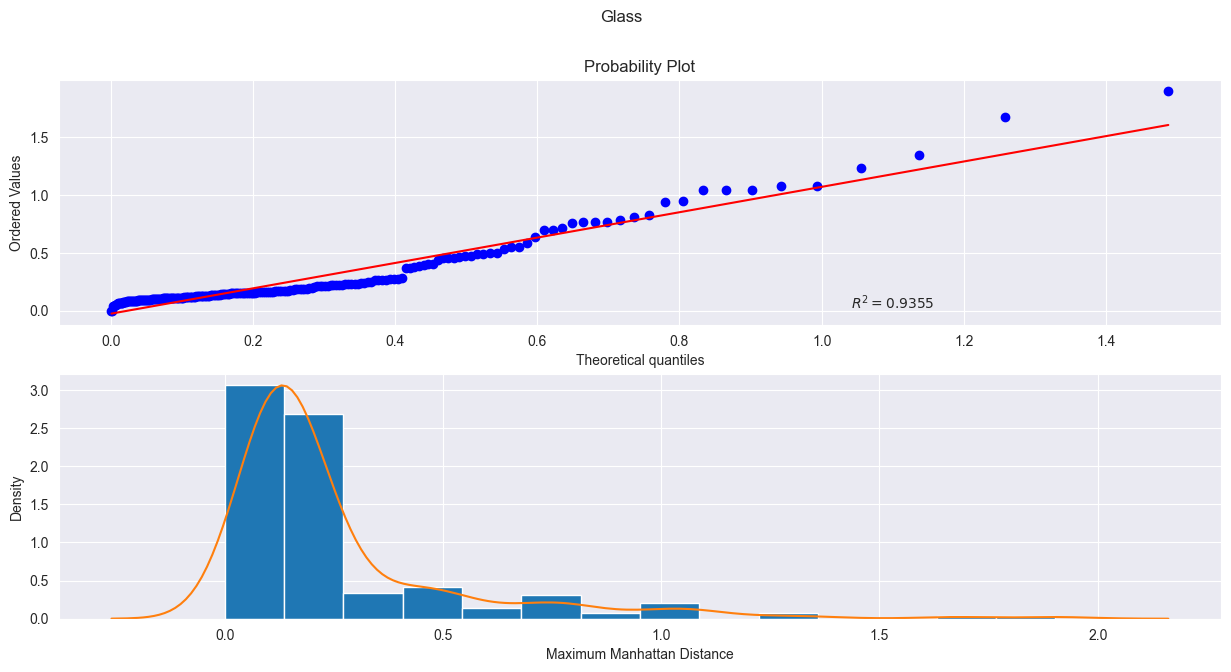

In [10]:
X, y = setupDf("real/Glass_withoutdupl_norm.arff")
endResults = outputResults(X, y)
printResults(endResults)
qqPlots(X,y,2,"Glass")

0.7761194029850746 39 [0.6222732491389208, 0.6165327210103329, 0.6285878300803673, 0.634902411021814, 0.6481056257175659, 0.669345579793341, 0.6831228473019517, 0.6848450057405281, 0.6871412169919632, 0.700918484500574, 0.7026406429391504, 0.7072330654420207, 0.7152698048220436, 0.7158438576349025, 0.7256027554535018, 0.7250287026406431, 0.7256027554535018, 0.7342135476463835, 0.7370838117106774, 0.7445464982778417, 0.7531572904707234, 0.7405281285878301, 0.7439724454649829, 0.754305396096441, 0.7531572904707233, 0.7520091848450058, 0.7548794489092997, 0.751435132032147, 0.7537313432835822, 0.7571756601607348, 0.7629161882893226, 0.7715269804822045, 0.7606199770378875, 0.7634902411021813, 0.7600459242250288, 0.7629161882893226, 0.7686567164179106, 0.7761194029850746, 0.7675086107921929, 0.7692307692307692, 0.7675086107921929, 0.769804822043628, 0.7669345579793341, 0.7652123995407577, 0.7709529276693455, 0.7715269804822044, 0.7686567164179104, 0.7715269804822042, 0.7715269804822044, 0.7

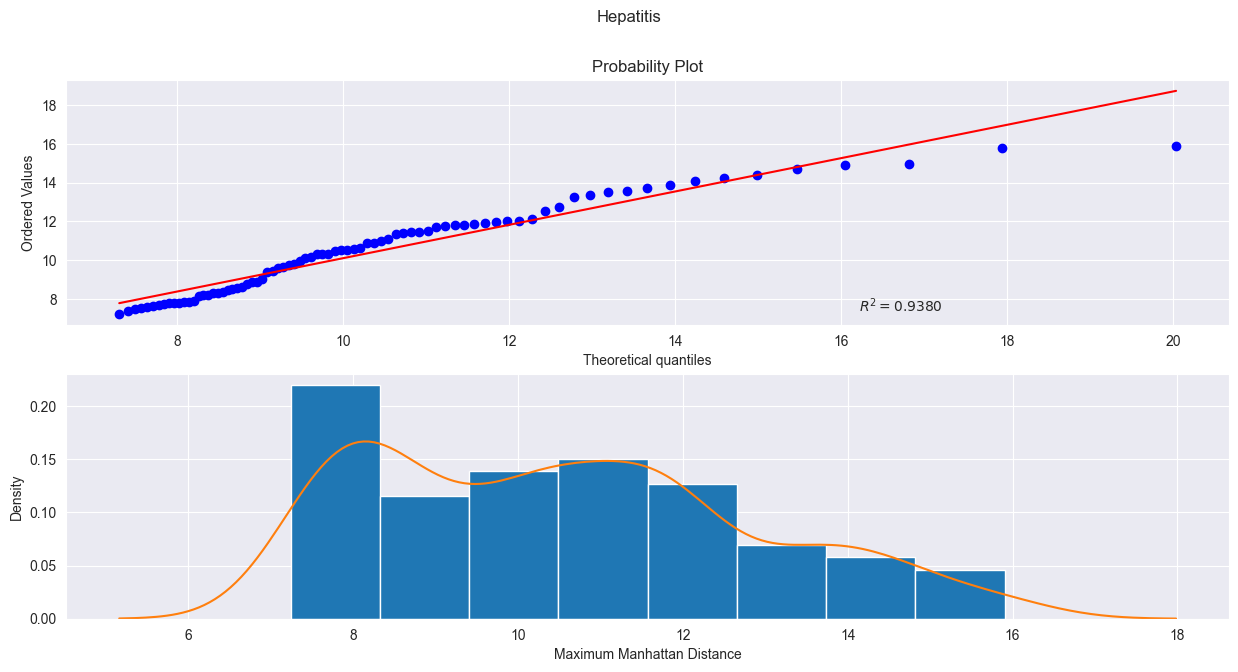

In [11]:
X, y = setupDf("real/Hepatitis_withoutdupl_norm_16.arff")
endResults = outputResults(X, y)
printResults(endResults)
qqPlots(X,y,39,"Hepatitis")

0.7331194029850746 68 [0.6767089552238807, 0.6867611940298508, 0.7004104477611941, 0.7044962686567164, 0.7105298507462686, 0.7139365671641791, 0.715608208955224, 0.7168246268656717, 0.7187611940298507, 0.718358208955224, 0.7184701492537315, 0.7199738805970151, 0.7221268656716416, 0.7215820895522389, 0.7213320895522389, 0.7211940298507462, 0.7225522388059703, 0.722723880597015, 0.7234179104477612, 0.7249179104477612, 0.725044776119403, 0.7240858208955224, 0.7241567164179106, 0.7252686567164178, 0.7246082089552239, 0.7248694029850746, 0.7248694029850746, 0.7241492537313434, 0.7247462686567164, 0.7251007462686568, 0.7265111940298508, 0.7266417910447761, 0.7263992537313432, 0.7270522388059703, 0.7277425373134327, 0.7274141791044777, 0.7275522388059701, 0.7265746268656715, 0.7279701492537314, 0.7282350746268658, 0.7288432835820896, 0.7282500000000001, 0.7292686567164179, 0.729723880597015, 0.7291828358208956, 0.7289813432835821, 0.7283358208955223, 0.7291828358208955, 0.7292462686567164, 0.

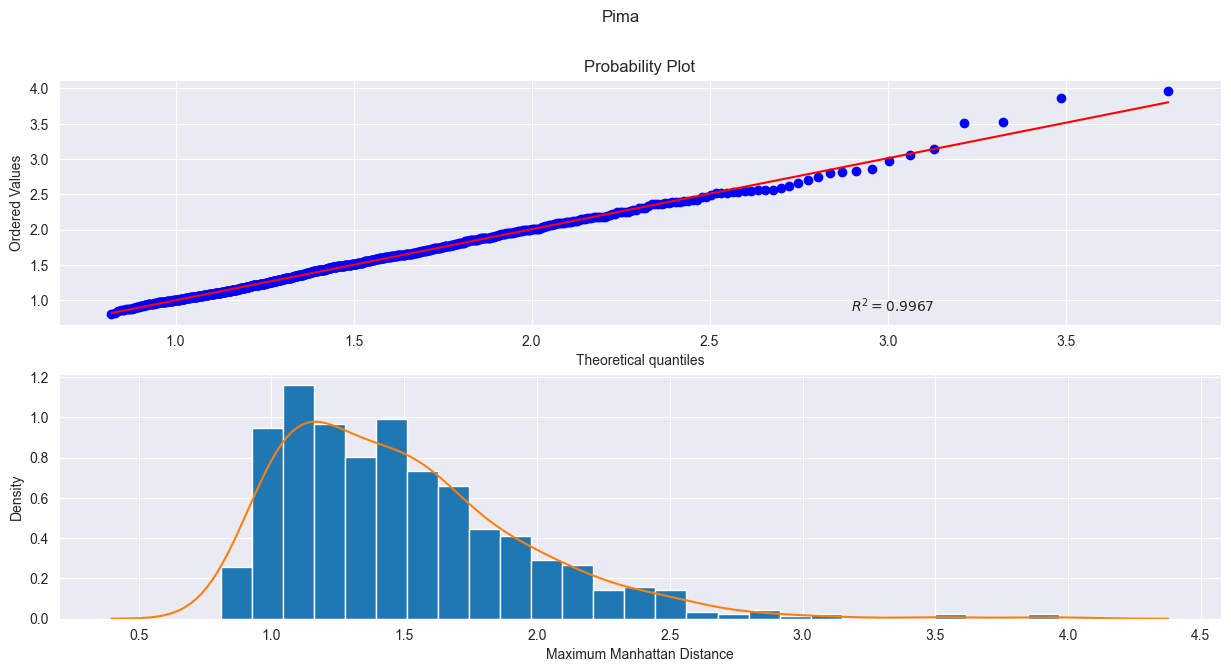

In [12]:
X, y = setupDf("real/Pima_withoutdupl_norm_35.arff")
endResults = outputResults(X, y)
printResults(endResults)
qqPlots(X,y,68,"Pima")

0.9839840576766856 12 [0.9270105605199025, 0.004670999187652347, 0.9679833468724613, 0.9781681559707555, 0.9778889114541024, 0.9785946385052803, 0.9801406376929326, 0.9819861900893584, 0.9831463241267264, 0.9827426888708368, 0.9839840576766856, 0.9829914703493096, 0.9832859463850528, 0.9830168562144598, 0.9833113322502031, 0.9829660844841591, 0.9826182981316003, 0.982501523151909, 0.9821029650690495, 0.9811433793663688, 0.9808184402924454, 0.9812043054427295, 0.9814073923639317, 0.9808590576766856, 0.9806864337936637, 0.9807778229082047, 0.9804935012185215, 0.9804528838342812, 0.9803310316815596, 0.9798334687246141, 0.9800771730300569, 0.9778508326563768, 0.977962530463038, 0.9778965272136474, 0.9781478472786354, 0.9781249999999999, 0.9780564581640943, 0.9777162875710803, 0.9674096263200649, 0.9773431153533712, 0.9771374898456537, 0.9768303208773355, 0.9771679528838342, 0.9769166328188463, 0.9767465475223397, 0.9769014012997564, 0.9768836311941511, 0.9766170796100732, 0.977051177904143

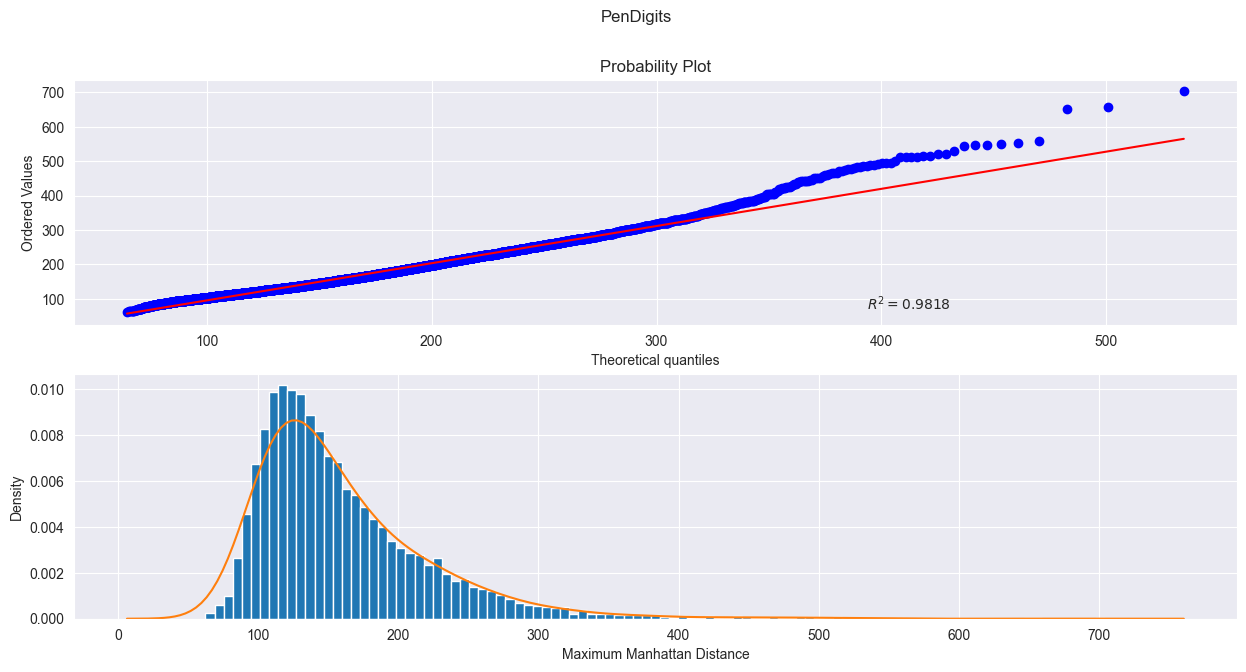

In [13]:
X, y = setupDf("real/PenDigits_withoutdupl_norm_v10.arff")
endResults = outputResults(X, y)
printResults(endResults)
qqPlots(X,y,12,"PenDigits")

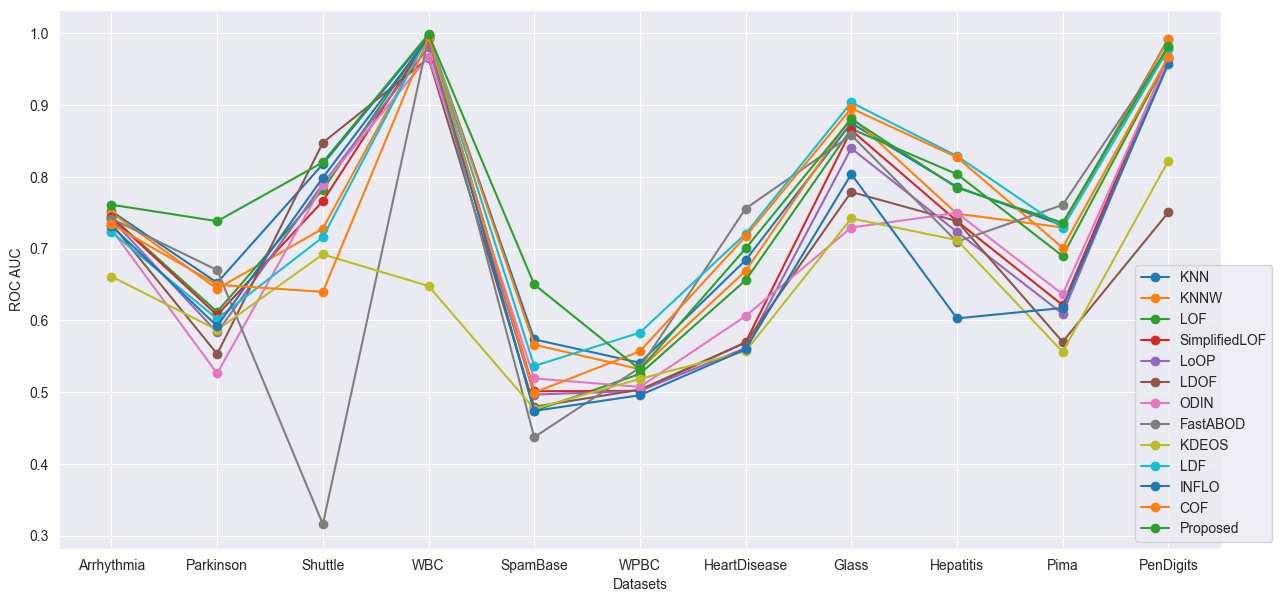

In [14]:
valuesperSet = [[0.752,0.75008,0.74421,0.74339,0.74111,0.73452,0.72669,0.74176,0.66101,0.72286,0.73154,0.73385,0.761081489734203],
[0.65235,0.64399,0.61196,0.60728,0.58312,0.55315,0.52608,0.66993,0.58673,0.60218,0.59198,0.64966,0.738166099773242],
[0.81762,0.72785,0.78208,0.76608,0.78992,0.84754,0.789,0.316,0.69192,0.71585,0.79885,0.63969,0.820153846153846],
[0.99718,0.99718,0.99671,0.9939,0.98028,0.96526,0.96737,0.99484,0.64789,0.99718,0.9939,0.99437,0.998591549295774],
[0.57347,0.56618,0.47384,0.50119,0.49658,0.4796,0.5191,0.43721,0.47667,0.53641,0.47381,0.49945,0.650009471053444],
[0.5409,0.53191,0.52543,0.50183,0.50183,0.50345,0.50726,0.53417,0.51853,0.58292,0.4957,0.55686,0.531562632098069],
[0.68383,0.66883,0.65583,0.56933,0.56139,0.56906,0.60592,0.75567,0.55694,0.72056,0.55967,0.71683,0.700166666666666],
[0.8748,0.8832,0.86667,0.86504,0.83957,0.77886,0.72927,0.85799,0.74201,0.90352,0.80379,0.89539,0.880487804878048],
[0.78588,0.74856,0.80367,0.73823,0.72331,0.73823,0.74971,0.70953,0.71183,0.82893,0.60276,0.82721,0.784730195177956],
[0.73224,0.72944,0.68955,0.62131,0.60922,0.57004,0.63637,0.76081,0.55621,0.72888,0.61728,0.70121,0.735914179104477],
[0.99212,0.9916,0.96581,0.9668,0.96231,0.75034,0.96432,0.97979,0.82214,0.97791,0.95712,0.96695,0.982605605199025],
]
datasets = ['Arrhythmia','Parkinson','Shuttle','WBC','SpamBase','WPBC','HeartDisease','Glass','Hepatitis','Pima','PenDigits']

algo = ['KNN','KNNW','LOF','SimplifiedLOF','LoOP','LDOF','ODIN','FastABOD','KDEOS','LDF','INFLO','COF','Proposed']

plt.plot(datasets,valuesperSet,marker='o')
plt.ylabel("ROC AUC")
plt.xlabel("Datasets")
plt.legend(algo,loc=4,bbox_to_anchor=(1.05,0))
plt.show()